<a href="https://colab.research.google.com/github/2005monicagarcia-arch/PortfolioOptimizationURE26/blob/Thao/01_DS1_ML_RF%2BSNN%2BLR%20_Walk-forward%20validation_Threshold%200.5%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving portfolio_option1_EFA_VNQ_20years.csv to portfolio_option1_EFA_VNQ_20years.csv


In [6]:
# ============================================================
# STAGE 1: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Stage 1 completed successfully.")

Stage 1 completed successfully.


In [7]:
# ============================================================
# STAGE 2: CHECK AVAILABLE DATA OBJECTS
# ============================================================

possible_variables = [
    "df",
    "data",
    "adj_close",
    "monthly_prices",
    "monthly_returns",
    "ml_data",
    "features"
]

for variable_name in possible_variables:
    print(
        variable_name,
        "exists:",
        variable_name in globals()
    )

print("\nAvailable DataFrames:")
%whos DataFrame

df exists: False
data exists: False
adj_close exists: False
monthly_prices exists: False
monthly_returns exists: False
ml_data exists: False
features exists: False

Available DataFrames:
No variables match your requested type.


In [8]:
# ============================================================
# STAGE 3A: UPLOAD DATA FILE
# ============================================================

from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print("-", filename)

Saving portfolio_option1_EFA_VNQ_20years.csv to portfolio_option1_EFA_VNQ_20years (1).csv
Uploaded files:
- portfolio_option1_EFA_VNQ_20years (1).csv


In [10]:
# ============================================================
# STAGE 3B: READ RAW CSV FILE
# ============================================================

import pandas as pd

FILE_NAME = list(uploaded.keys())[0]

raw_data = pd.read_csv(
    FILE_NAME,
    header=[0, 1],
    index_col=0,
    parse_dates=True
)

print("File loaded successfully.")
print("Shape:", raw_data.shape)
print("Date range:", raw_data.index.min(), "to", raw_data.index.max())

display(raw_data.head())

File loaded successfully.
Shape: (5153, 54)
Date range: 2006-01-03 00:00:00 to 2026-06-29 00:00:00


Price      Adj Close                                                        \
Ticker          AAPL        EFA        IEF       MSFT      NVDA        QQQ   
Date                                                                         
2006-01-03  2.237673  33.620350  49.090813  18.632084  0.291656  35.273769   
2006-01-04  2.244259  33.899529  49.178551  18.722328  0.299822  35.640934   
2006-01-05  2.226598  33.729832  49.190231  18.736214  0.306612  35.794636   
2006-01-06  2.284073  34.184166  49.125893  18.680685  0.311649  36.443584   
2006-01-09  2.276588  34.200577  49.149277  18.645973  0.320348  36.588745   

Price                                           Close  ...       Open  \
Ticker            SPY        TLT        VNQ      AAPL  ...        VNQ   
Date                                                   ...              
2006-01-03  87.000908  47.859772  25.824440  2.669643  ...  59.939999   
2006-01-04  87.412918  47.974487  26.015696  2.677500  ...  61.209999   
2006-01-05  87.467857  47.917107  26.215464  2.656429  ...  61.240002   
2006-01-06  88.195740  47.828461  26.461979  2.725000  ...  62.009998   
2006-01-09  88.422348  47.859772  26.687244  2.716071  ...  62.599998   

Price          Volume                                                    \
Ticker           AAPL      EFA     IEF       MSFT       NVDA        QQQ   
Date                                                                      
2006-01-03  807234400  7778500  299500   79973000  472812000  109350400   
2006-01-04  619603600  5231500  112300   57975600  510072000   92769400   
2006-01-05  449422400  4953800  159700   48245500  646092000   77656900   
2006-01-06  704457600  5326600  179100  100963000  623388000  110053900   
2006-01-09  675040800  3057200   78600   55625000  560484000   80768800   

Price                                 
Ticker           SPY      TLT    VNQ  
Date                                  
2006-01-03  73256700  1392700  70300  
2006-01-04  51899600   387600  75000  
2006-01-05  47307500   453400  31200  
2006-01-06  62885900  1193700  36000  
2006-01-09  43527400   413600  49200  

[5 rows x 54 columns]

In [11]:
# ============================================================
# STAGE 4: EXTRACT PRICES AND CREATE MONTHLY RETURNS
# ============================================================

# Check available first-level columns
print("Top-level columns:")
print(raw_data.columns.get_level_values(0).unique().tolist())

# Use Adjusted Close if available; otherwise use Close
if "Adj Close" in raw_data.columns.get_level_values(0):
    adjusted_close = raw_data["Adj Close"].copy()
elif "Close" in raw_data.columns.get_level_values(0):
    adjusted_close = raw_data["Close"].copy()
else:
    raise ValueError(
        "Could not find 'Adj Close' or 'Close' in the dataset."
    )

# Clean column names
adjusted_close.columns.name = None
adjusted_close = adjusted_close.sort_index()

# Convert daily prices to month-end prices
monthly_prices = adjusted_close.resample("ME").last()

# Calculate monthly returns
monthly_returns = monthly_prices.pct_change()

# Remove rows where all assets are missing
monthly_prices = monthly_prices.dropna(how="all")
monthly_returns = monthly_returns.dropna(how="all")

print("\nStage 4 completed successfully.")
print("Assets:", monthly_prices.columns.tolist())
print("Monthly price shape:", monthly_prices.shape)
print("Monthly return shape:", monthly_returns.shape)
print(
    "Monthly date range:",
    monthly_returns.index.min(),
    "to",
    monthly_returns.index.max()
)

display(monthly_prices.head())
display(monthly_returns.head())

Top-level columns:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Stage 4 completed successfully.
Assets: ['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']
Monthly price shape: (246, 9)
Monthly return shape: (245, 9)
Monthly date range: 2006-02-28 00:00:00 to 2026-06-30 00:00:00


,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2006-01-31,2.260425,34.408585,48.751446,19.541477,0.343089,35.862942,87.550270,47.280918,27.222775
2006-02-28,2.050277,34.167732,48.700985,18.716116,0.359648,35.094440,88.051537,47.804810,27.728548
2006-03-31,1.877549,35.536201,48.039654,18.952944,0.436950,35.828281,89.504730,45.620144,29.035961
2006-04-30,2.107155,37.238564,47.738392,16.821518,0.445954,35.759937,90.635361,44.364506,28.048433
2006-05-31,1.789241,35.815361,47.687382,15.838223,0.350720,33.170868,87.905327,44.279793,27.291752


,AAPL,EFA,IEF,MSFT,NVDA,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,
2006-02-28,-0.092969,-0.007000,-0.001035,-0.042236,0.048264,-0.021429,0.005725,0.011080,0.018579
2006-03-31,-0.084246,0.040052,-0.013579,0.012654,0.214938,0.020910,0.016504,-0.045700,0.047150
2006-04-30,0.122290,0.047905,-0.006271,-0.112459,0.020607,-0.001908,0.012632,-0.027524,-0.034011
2006-05-31,-0.150873,-0.038219,-0.001069,-0.058455,-0.213553,-0.072401,-0.030121,-0.001909,-0.026978
2006-06-30,-0.041828,-0.000611,0.002297,0.028698,-0.073543,-0.000616,0.002608,0.011783,0.049610


In [12]:
# ============================================================
# STAGE 5: CREATE MACHINE LEARNING DATASET
# ============================================================

feature_data = []

for ticker in monthly_returns.columns:

    temp = pd.DataFrame(
        index=monthly_returns.index
    )

    temp["ticker"] = ticker

    # Lagged return features
    temp["return_1m"] = (
        monthly_returns[ticker]
        .shift(1)
    )

    temp["return_3m"] = (
        monthly_returns[ticker]
        .rolling(3)
        .sum()
        .shift(1)
    )

    temp["return_6m"] = (
        monthly_returns[ticker]
        .rolling(6)
        .sum()
        .shift(1)
    )

    # Lagged volatility features
    temp["volatility_3m"] = (
        monthly_returns[ticker]
        .rolling(3)
        .std()
        .shift(1)
    )

    temp["volatility_6m"] = (
        monthly_returns[ticker]
        .rolling(6)
        .std()
        .shift(1)
    )

    # Lagged trend feature
    moving_average_3m = (
        monthly_prices[ticker]
        .rolling(3)
        .mean()
    )

    temp["trend_signal"] = (
        monthly_prices[ticker]
        .shift(1)
        >
        moving_average_3m.shift(1)
    ).astype(int)

    # Current-month return used as realized portfolio return
    temp["actual_return"] = monthly_returns[ticker]

    # Classification target:
    # 1 = positive current-month return
    # 0 = zero or negative current-month return
    temp["target"] = (
        temp["actual_return"] > 0
    ).astype(int)

    feature_data.append(temp)


ml_data = pd.concat(
    feature_data
).sort_index()

features = [
    "return_1m",
    "return_3m",
    "return_6m",
    "volatility_3m",
    "volatility_6m",
    "trend_signal"
]

required_columns = (
    features
    + [
        "ticker",
        "actual_return",
        "target"
    ]
)

ml_data = ml_data[
    required_columns
].dropna()

print("Stage 5 completed successfully.")
print("ML dataset shape:", ml_data.shape)
print("Date range:", ml_data.index.min(), "to", ml_data.index.max())
print("Assets:", ml_data["ticker"].unique().tolist())
print("Features:", features)

print("\nTarget distribution:")
display(
    ml_data["target"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Negative/Zero Return",
        1: "Positive Return"
    })
    .to_frame("Count")
)

display(ml_data.head(10))

Stage 5 completed successfully.
ML dataset shape: (2151, 9)
Date range: 2006-08-31 00:00:00 to 2026-06-30 00:00:00
Assets: ['TLT', 'IEF', 'QQQ', 'MSFT', 'EFA', 'AAPL', 'VNQ', 'NVDA', 'SPY']
Features: ['return_1m', 'return_3m', 'return_6m', 'volatility_3m', 'volatility_6m', 'trend_signal']

Target distribution:


,Count
target,
Negative/Zero Return,864
Positive Return,1287


,return_1m,return_3m,return_6m,volatility_3m,volatility_6m,trend_signal,ticker,actual_return,target
Date,,,,,,,,,
2006-08-31,0.021633,0.031506,-0.030637,0.011823,0.026164,1,TLT,0.030562,1
2006-08-31,0.016772,0.018001,-0.002885,0.009479,0.010111,1,IEF,0.017636,1
2006-08-31,-0.043075,-0.116092,-0.118518,0.036093,0.033636,0,QQQ,0.047710,1
2006-08-31,0.032618,0.002861,-0.139180,0.051487,0.057736,1,MSFT,0.072096,1
2006-08-31,0.008106,-0.030724,0.050232,0.024618,0.031794,1,EFA,0.025485,1
2006-08-31,0.186660,-0.006041,-0.060966,0.172253,0.133739,1,AAPL,-0.001619,0
2006-08-31,0.038914,0.061547,0.093266,0.041477,0.037359,1,VNQ,0.034843,1
2006-08-31,0.039926,-0.247169,0.036640,0.126971,0.142363,1,NVDA,0.314815,1
2006-08-31,0.004478,-0.023035,0.011827,0.019459,0.016586,1,SPY,0.021822,1


In [13]:
# ============================================================
# STAGE 6: WALK-FORWARD VALIDATION FOR THREE MODELS
# Logistic Regression + Random Forest + SNN
# ============================================================

walk_forward_results_list = []

# Unique monthly dates
all_dates = sorted(
    ml_data.index.unique()
)

# Use the first 60 months as the initial training period
MIN_TRAIN_MONTHS = 60

print("Total available months:", len(all_dates))
print("Initial training months:", MIN_TRAIN_MONTHS)
print(
    "Number of walk-forward test months:",
    len(all_dates) - MIN_TRAIN_MONTHS
)

for i in range(
    MIN_TRAIN_MONTHS,
    len(all_dates)
):

    train_dates = all_dates[:i]
    test_date = all_dates[i]

    # Historical data only
    train_data = ml_data[
        ml_data.index.isin(train_dates)
    ].copy()

    # Current test month
    test_data = ml_data[
        ml_data.index == test_date
    ].copy()

    X_train = train_data[features]
    y_train = train_data["target"].astype(int)

    X_test = test_data[features]
    y_test = test_data["target"].astype(int)

    # Skip month if test data are empty
    if len(test_data) == 0:
        continue

    # --------------------------------------------------------
    # 1. LOGISTIC REGRESSION
    # --------------------------------------------------------

    logistic_model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ])

    logistic_model.fit(
        X_train,
        y_train
    )

    log_probability = (
        logistic_model
        .predict_proba(X_test)[:, 1]
    )

    log_prediction = (
        log_probability >= 0.50
    ).astype(int)

    # --------------------------------------------------------
    # 2. RANDOM FOREST
    # --------------------------------------------------------

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(
        X_train,
        y_train
    )

    rf_probability = (
        rf_model
        .predict_proba(X_test)[:, 1]
    )

    rf_prediction = (
        rf_probability >= 0.50
    ).astype(int)

    # --------------------------------------------------------
    # 3. SIMPLE NEURAL NETWORK
    # --------------------------------------------------------

    snn_model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=(16, 8),
                activation="relu",
                solver="adam",
                alpha=0.001,
                learning_rate_init=0.001,
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                random_state=42
            )
        )
    ])

    snn_model.fit(
        X_train,
        y_train
    )

    snn_probability = (
        snn_model
        .predict_proba(X_test)[:, 1]
    )

    snn_prediction = (
        snn_probability >= 0.50
    ).astype(int)

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    month_results = test_data[
        [
            "ticker",
            "actual_return",
            "target"
        ]
    ].copy()

    month_results["test_date"] = test_date

    month_results[
        "logistic_probability"
    ] = log_probability

    month_results[
        "logistic_prediction"
    ] = log_prediction

    month_results[
        "rf_probability"
    ] = rf_probability

    month_results[
        "rf_prediction"
    ] = rf_prediction

    month_results[
        "snn_probability"
    ] = snn_probability

    month_results[
        "snn_prediction"
    ] = snn_prediction

    walk_forward_results_list.append(
        month_results
    )

    # Progress update every 12 test months
    completed_months = (
        i - MIN_TRAIN_MONTHS + 1
    )

    if completed_months % 12 == 0:
        print(
            f"Completed {completed_months} "
            f"test months through "
            f"{pd.Timestamp(test_date).strftime('%Y-%m')}"
        )


walk_forward_results = pd.concat(
    walk_forward_results_list
).sort_index()

print("\nStage 6 completed successfully.")
print(
    "Walk-forward result shape:",
    walk_forward_results.shape
)
print(
    "Test period:",
    walk_forward_results.index.min(),
    "to",
    walk_forward_results.index.max()
)

print("\nResult columns:")
print(
    walk_forward_results.columns.tolist()
)

display(
    walk_forward_results.head(10)
)

Total available months: 239
Initial training months: 60
Number of walk-forward test months: 179
Completed 12 test months through 2012-07
Completed 24 test months through 2013-07
Completed 36 test months through 2014-07
Completed 48 test months through 2015-07
Completed 60 test months through 2016-07
Completed 72 test months through 2017-07
Completed 84 test months through 2018-07
Completed 96 test months through 2019-07
Completed 108 test months through 2020-07
Completed 120 test months through 2021-07
Completed 132 test months through 2022-07
Completed 144 test months through 2023-07
Completed 156 test months through 2024-07
Completed 168 test months through 2025-07

Stage 6 completed successfully.
Walk-forward result shape: (1611, 10)
Test period: 2011-08-31 00:00:00 to 2026-06-30 00:00:00

Result columns:
['ticker', 'actual_return', 'target', 'test_date', 'logistic_probability', 'logistic_prediction', 'rf_probability', 'rf_prediction', 'snn_probability', 'snn_prediction']


,ticker,actual_return,target,test_date,logistic_probability,logistic_prediction,rf_probability,rf_prediction,snn_probability,snn_prediction
Date,,,,,,,,,,
2011-08-31,AAPL,-0.014469,0,2011-08-31,0.652576,1,0.726263,1,0.582535,1
2011-08-31,EFA,-0.087549,0,2011-08-31,0.566267,1,0.536188,1,0.646408,1
2011-08-31,VNQ,-0.056193,0,2011-08-31,0.582388,1,0.535026,1,0.674731,1
2011-08-31,QQQ,-0.050689,0,2011-08-31,0.589461,1,0.624157,1,0.598813,1
2011-08-31,NVDA,-0.037600,0,2011-08-31,0.485771,0,0.355063,0,0.363280,0
2011-08-31,SPY,-0.054976,0,2011-08-31,0.571582,1,0.576082,1,0.654457,1
2011-08-31,MSFT,-0.023070,0,2011-08-31,0.634838,1,0.642700,1,0.596589,1
2011-08-31,TLT,0.096674,1,2011-08-31,0.611516,1,0.660179,1,0.604670,1
2011-08-31,IEF,0.046514,1,2011-08-31,0.615982,1,0.653310,1,0.591060,1



Logistic Regression
                 precision    recall  f1-score   support

Negative Return     0.3043    0.0109    0.0211       640
Positive Return     0.6014    0.9835    0.7464       971

       accuracy                         0.5971      1611
      macro avg     0.4529    0.4972    0.3838      1611
   weighted avg     0.4834    0.5971    0.4583      1611



,Predicted Negative Return,Predicted Positive Return
Actual Negative Return,7,633
Actual Positive Return,16,955


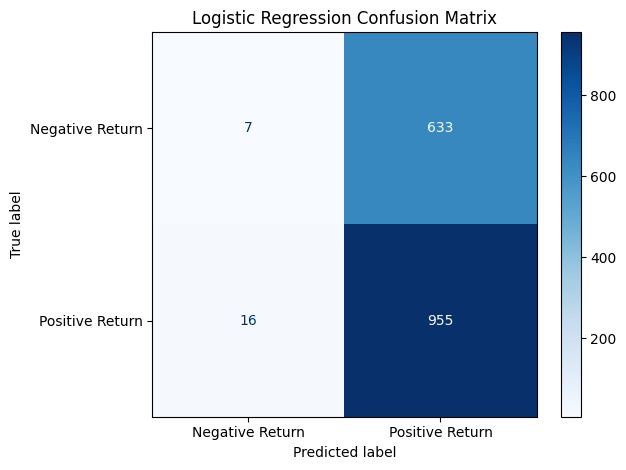


Random Forest
                 precision    recall  f1-score   support

Negative Return     0.2500    0.0234    0.0429       640
Positive Return     0.5970    0.9537    0.7343       971

       accuracy                         0.5841      1611
      macro avg     0.4235    0.4885    0.3886      1611
   weighted avg     0.4592    0.5841    0.4596      1611



,Predicted Negative Return,Predicted Positive Return
Actual Negative Return,15,625
Actual Positive Return,45,926


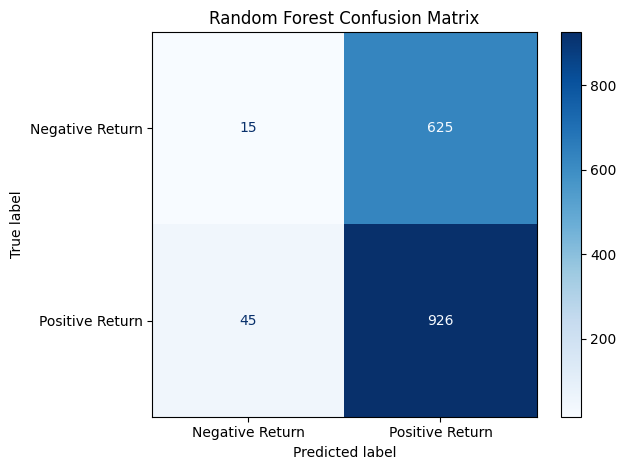


Simple Neural Network
                 precision    recall  f1-score   support

Negative Return     0.3824    0.0203    0.0386       640
Positive Return     0.6024    0.9784    0.7457       971

       accuracy                         0.5978      1611
      macro avg     0.4924    0.4993    0.3921      1611
   weighted avg     0.5150    0.5978    0.4648      1611



,Predicted Negative Return,Predicted Positive Return
Actual Negative Return,13,627
Actual Positive Return,21,950


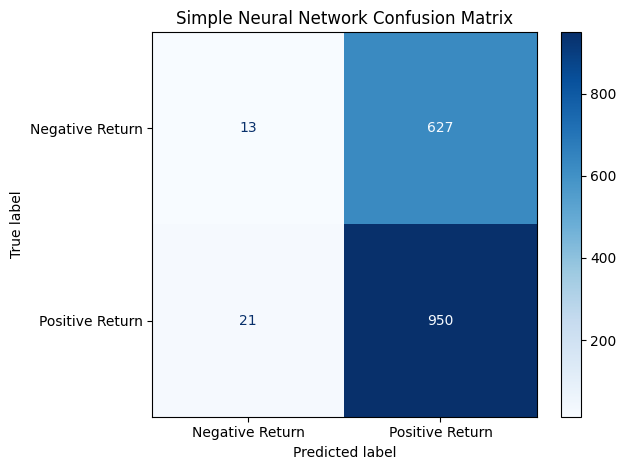


Classification Comparison


,Model,Accuracy,Balanced Accuracy,Positive Precision,Positive Recall,Negative Recall,Positive F1,Actual Positive Rate,Predicted Positive Rate,TN,FP,FN,TP
0,Logistic Regression,59.71%,49.72%,60.14%,98.35%,1.09%,74.64%,60.27%,98.57%,7,633,16,955
1,Random Forest,58.41%,48.85%,59.70%,95.37%,2.34%,73.43%,60.27%,96.28%,15,625,45,926
2,Simple Neural Network,59.78%,49.93%,60.24%,97.84%,2.03%,74.57%,60.27%,97.89%,13,627,21,950


In [14]:
# ============================================================
# STAGE 7: CLASSIFICATION REPORTS AND CONFUSION MATRICES
# ============================================================

y_true = walk_forward_results["target"].astype(int)

model_prediction_columns = {
    "Logistic Regression": "logistic_prediction",
    "Random Forest": "rf_prediction",
    "Simple Neural Network": "snn_prediction"
}

classification_rows = []

for model_name, prediction_column in model_prediction_columns.items():

    y_pred = walk_forward_results[
        prediction_column
    ].astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    classification_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy":
            balanced_accuracy_score(y_true, y_pred),
        "Positive Precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),
        "Positive Recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),
        "Negative Recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),
        "Positive F1":
            f1_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),
        "Actual Positive Rate": y_true.mean(),
        "Predicted Positive Rate": y_pred.mean(),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Negative Return",
                "Positive Return"
            ],
            digits=4,
            zero_division=0
        )
    )

    confusion_table = pd.DataFrame(
        [
            [tn, fp],
            [fn, tp]
        ],
        index=[
            "Actual Negative Return",
            "Actual Positive Return"
        ],
        columns=[
            "Predicted Negative Return",
            "Predicted Positive Return"
        ]
    )

    display(confusion_table)

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=np.array([
            [tn, fp],
            [fn, tp]
        ]),
        display_labels=[
            "Negative Return",
            "Positive Return"
        ]
    )

    display_matrix.plot(
        values_format="d",
        cmap="Blues"
    )

    plt.title(
        f"{model_name} Confusion Matrix"
    )
    plt.tight_layout()
    plt.show()


classification_comparison = pd.DataFrame(
    classification_rows
)

print("\nClassification Comparison")

display(
    classification_comparison.style.format({
        "Accuracy": "{:.2%}",
        "Balanced Accuracy": "{:.2%}",
        "Positive Precision": "{:.2%}",
        "Positive Recall": "{:.2%}",
        "Negative Recall": "{:.2%}",
        "Positive F1": "{:.2%}",
        "Actual Positive Rate": "{:.2%}",
        "Predicted Positive Rate": "{:.2%}"
    })
)

In [15]:
# ============================================================
# STAGE 8: BUILD PORTFOLIOS FOR THREE MODELS
# ============================================================

def build_model_portfolio(
    prediction_data,
    prediction_column
):

    portfolio_rows = []

    for date, month_data in prediction_data.groupby(
        prediction_data.index
    ):

        selected_assets = month_data[
            month_data[prediction_column] == 1
        ]

        if len(selected_assets) > 0:

            portfolio_return = selected_assets[
                "actual_return"
            ].mean()

            selected_tickers = selected_assets[
                "ticker"
            ].tolist()

        else:

            portfolio_return = 0.0
            selected_tickers = []

        portfolio_rows.append({
            "Date": date,
            "Portfolio_Return": portfolio_return,
            "Selected_Assets": selected_tickers,
            "Number_of_Assets": len(selected_tickers)
        })

    portfolio_df = pd.DataFrame(
        portfolio_rows
    )

    portfolio_df["Date"] = pd.to_datetime(
        portfolio_df["Date"]
    )

    portfolio_df = (
        portfolio_df
        .sort_values("Date")
        .set_index("Date")
    )

    return portfolio_df


logistic_portfolio = build_model_portfolio(
    walk_forward_results,
    "logistic_prediction"
)

rf_portfolio = build_model_portfolio(
    walk_forward_results,
    "rf_prediction"
)

snn_portfolio = build_model_portfolio(
    walk_forward_results,
    "snn_prediction"
)


print("Stage 8 completed successfully.")

print("\nLogistic Regression Portfolio")
display(logistic_portfolio.head())

print("\nRandom Forest Portfolio")
display(rf_portfolio.head())

print("\nSimple Neural Network Portfolio")
display(snn_portfolio.head())

Stage 8 completed successfully.

Logistic Regression Portfolio


,Portfolio_Return,Selected_Assets,Number_of_Assets
Date,,,
2011-08-31,-0.017970,"[AAPL, EFA, VNQ, QQQ, SPY, MSFT, TLT, IEF]",8
2011-09-30,-0.034435,"[AAPL, MSFT, EFA, SPY, QQQ, IEF, TLT, VNQ, NVDA]",9
2011-10-31,0.068070,"[IEF, SPY, TLT, QQQ, MSFT, AAPL, NVDA]",7
2011-11-30,-0.010774,"[VNQ, AAPL, SPY, IEF, MSFT, QQQ, NVDA, EFA, TLT]",9
2011-12-31,0.005184,"[NVDA, MSFT, SPY, TLT, VNQ, EFA, QQQ, IEF, AAPL]",9



Random Forest Portfolio


,Portfolio_Return,Selected_Assets,Number_of_Assets
Date,,,
2011-08-31,-0.017970,"[AAPL, EFA, VNQ, QQQ, SPY, MSFT, TLT, IEF]",8
2011-09-30,-0.025229,"[AAPL, MSFT, SPY, QQQ, IEF, TLT, VNQ, NVDA]",8
2011-10-31,0.067764,"[IEF, SPY, TLT, QQQ, AAPL, NVDA]",6
2011-11-30,-0.010774,"[VNQ, AAPL, SPY, IEF, MSFT, QQQ, NVDA, EFA, TLT]",9
2011-12-31,0.003975,"[NVDA, SPY, TLT, VNQ, EFA, QQQ, IEF, AAPL]",8



Simple Neural Network Portfolio


,Portfolio_Return,Selected_Assets,Number_of_Assets
Date,,,
2011-08-31,-0.017970,"[AAPL, EFA, VNQ, QQQ, SPY, MSFT, TLT, IEF]",8
2011-09-30,-0.034435,"[AAPL, MSFT, EFA, SPY, QQQ, IEF, TLT, VNQ, NVDA]",9
2011-10-31,0.079520,"[IEF, SPY, TLT, VNQ, QQQ, MSFT, AAPL, EFA, NVDA]",9
2011-11-30,-0.010774,"[VNQ, AAPL, SPY, IEF, MSFT, QQQ, NVDA, EFA, TLT]",9
2011-12-31,0.005184,"[NVDA, MSFT, SPY, TLT, VNQ, EFA, QQQ, IEF, AAPL]",9


In [17]:
# ============================================================
# STAGE 9A-1: WALK-FORWARD MEAN-VARIANCE OPTIMIZATION
# ============================================================

mvo_rows = []

all_test_dates = comparison_returns.index

for test_date in all_test_dates:

    # Use only historical monthly returns before the test month
    historical_returns = monthly_returns[
        monthly_returns.index < test_date
    ].dropna()

    # Require enough historical observations
    if len(historical_returns) < 24:
        mvo_rows.append({
            "Date": test_date,
            "MVO_Return": np.nan
        })
        continue

    # Expected annual return
    expected_returns = (
        historical_returns.mean() * 12
    )

    # Annualized covariance matrix
    covariance_matrix = (
        historical_returns.cov() * 12
    )

    # Add small regularization for numerical stability
    regularized_covariance = (
        covariance_matrix
        + np.eye(len(covariance_matrix)) * 1e-6
    )

    inverse_covariance = np.linalg.pinv(
        regularized_covariance.values
    )

    raw_weights = inverse_covariance @ expected_returns.values

    # Long-only approximation:
    # negative weights are set to zero
    raw_weights = np.maximum(
        raw_weights,
        0
    )

    if raw_weights.sum() == 0:
        weights = np.repeat(
            1 / len(raw_weights),
            len(raw_weights)
        )
    else:
        weights = (
            raw_weights / raw_weights.sum()
        )

    current_returns = monthly_returns.loc[
        test_date,
        historical_returns.columns
    ]

    mvo_return = np.dot(
        weights,
        current_returns.values
    )

    mvo_rows.append({
        "Date": test_date,
        "MVO_Return": mvo_return
    })


mvo_portfolio = pd.DataFrame(
    mvo_rows
)

mvo_portfolio["Date"] = pd.to_datetime(
    mvo_portfolio["Date"]
)

mvo_portfolio = (
    mvo_portfolio
    .set_index("Date")
    .sort_index()
)

print("MVO portfolio created successfully.")

display(
    mvo_portfolio.head()
)

MVO portfolio created successfully.


,MVO_Return
Date,
2011-08-31,0.032179
2011-09-30,0.009455
2011-10-31,0.008098
2011-11-30,-0.002054
2011-12-31,0.023013


In [16]:
# ============================================================
# STAGE 9A: BUILD BENCHMARK RETURNS
# ============================================================

test_dates = logistic_portfolio.index

test_monthly_returns = (
    monthly_returns
    .reindex(test_dates)
    .copy()
)

# 1. Buy and Hold SPY
spy_returns = test_monthly_returns["SPY"]

# 2. Equal Weight
equal_weight_returns = (
    test_monthly_returns.mean(axis=1)
)

# 3. 60/40 Portfolio
# 60% SPY + 20% IEF + 20% TLT
portfolio_6040_returns = (
    0.60 * test_monthly_returns["SPY"]
    + 0.20 * test_monthly_returns["IEF"]
    + 0.20 * test_monthly_returns["TLT"]
)

comparison_returns = pd.DataFrame({
    "SPY": spy_returns,
    "Equal Weight": equal_weight_returns,
    "60/40 Portfolio": portfolio_6040_returns,
    "Logistic Regression":
        logistic_portfolio["Portfolio_Return"],
    "Random Forest":
        rf_portfolio["Portfolio_Return"],
    "Simple Neural Network":
        snn_portfolio["Portfolio_Return"]
}).dropna()

print("Stage 9A completed successfully.")
print("Comparison shape:", comparison_returns.shape)
print("Date range:", comparison_returns.index.min(), "to", comparison_returns.index.max())

display(comparison_returns.head())

Stage 9A completed successfully.
Comparison shape: (179, 6)
Date range: 2011-08-31 00:00:00 to 2026-06-30 00:00:00


,SPY,Equal Weight,60/40 Portfolio,Logistic Regression,Random Forest,Simple Neural Network
Date,,,,,,
2011-08-31,-0.054976,-0.020151,-0.004348,-0.017970,-0.017970,-0.017970
2011-09-30,-0.069421,-0.034435,-0.010766,-0.034435,-0.025229,-0.034435
2011-10-31,0.109147,0.079520,0.055257,0.068070,0.067764,0.079520
2011-11-30,-0.004064,-0.010774,0.002700,-0.010774,-0.010774,-0.010774
2011-12-31,0.010449,0.005184,0.017134,0.005184,0.003975,0.005184


In [19]:
# ============================================================
# STAGE 9A-2: COMBINE BENCHMARKS AND ML PORTFOLIOS
# ============================================================

test_dates = logistic_portfolio.index

test_monthly_returns = (
    monthly_returns
    .reindex(test_dates)
    .copy()
)

spy_returns = test_monthly_returns["SPY"]

equal_weight_returns = (
    test_monthly_returns.mean(axis=1)
)

portfolio_6040_returns = (
    0.60 * test_monthly_returns["SPY"]
    + 0.20 * test_monthly_returns["IEF"]
    + 0.20 * test_monthly_returns["TLT"]
)

comparison_returns = pd.DataFrame({
    "SPY": spy_returns,
    "Equal Weight": equal_weight_returns,
    "60/40 Portfolio": portfolio_6040_returns,
    "Mean-Variance Optimization":
        mvo_portfolio["MVO_Return"],
    "Logistic Regression":
        logistic_portfolio["Portfolio_Return"],
    "Random Forest":
        rf_portfolio["Portfolio_Return"],
    "Simple Neural Network":
        snn_portfolio["Portfolio_Return"]
}).dropna()

print("Comparison returns created successfully.")
print("Shape:", comparison_returns.shape)
print(
    "Date range:",
    comparison_returns.index.min(),
    "to",
    comparison_returns.index.max()
)

display(
    comparison_returns.head()
)

Comparison returns created successfully.
Shape: (179, 7)
Date range: 2011-08-31 00:00:00 to 2026-06-30 00:00:00


,SPY,Equal Weight,60/40 Portfolio,Mean-Variance Optimization,Logistic Regression,Random Forest,Simple Neural Network
Date,,,,,,,
2011-08-31,-0.054976,-0.020151,-0.004348,0.032179,-0.017970,-0.017970,-0.017970
2011-09-30,-0.069421,-0.034435,-0.010766,0.009455,-0.034435,-0.025229,-0.034435
2011-10-31,0.109147,0.079520,0.055257,0.008098,0.068070,0.067764,0.079520
2011-11-30,-0.004064,-0.010774,0.002700,-0.002054,-0.010774,-0.010774,-0.010774
2011-12-31,0.010449,0.005184,0.017134,0.023013,0.005184,0.003975,0.005184


In [21]:
# ============================================================
# STAGE 9B: PERFORMANCE COMPARISON
# ============================================================

def calculate_portfolio_metrics(
    returns,
    periods_per_year=12
):
    returns = returns.dropna()

    cumulative_growth = (1 + returns).cumprod()

    total_return = cumulative_growth.iloc[-1] - 1

    years = len(returns) / periods_per_year

    cagr = (
        cumulative_growth.iloc[-1] ** (1 / years)
        - 1
    )

    annual_volatility = (
        returns.std()
        * np.sqrt(periods_per_year)
    )

    annual_return = (
        returns.mean()
        * periods_per_year
    )

    sharpe_ratio = (
        annual_return / annual_volatility
        if annual_volatility > 0
        else np.nan
    )

    running_peak = cumulative_growth.cummax()

    drawdown = (
        cumulative_growth / running_peak
        - 1
    )

    maximum_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown
    }


performance_rows = []

for strategy in comparison_returns.columns:

    metrics = calculate_portfolio_metrics(
        comparison_returns[strategy]
    )

    performance_rows.append({
        "Portfolio": strategy,
        "Total Return": metrics["Total Return"],
        "CAGR": metrics["CAGR"],
        "Annual Volatility": metrics["Annual Volatility"],
        "Sharpe Ratio": metrics["Sharpe Ratio"],
        "Maximum Drawdown": metrics["Maximum Drawdown"]
    })


performance_table = pd.DataFrame(
    performance_rows
).sort_values(
    "Sharpe Ratio",
    ascending=False
).reset_index(drop=True)

print("Performance Comparison")

display(
    performance_table.style.format({
        "Total Return": "{:.2%}",
        "CAGR": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

Performance Comparison


,Portfolio,Total Return,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
0,Logistic Regression,1013.63%,17.54%,13.72%,1.253,-31.02%
1,Equal Weight,1007.46%,17.49%,14.00%,1.228,-30.23%
2,Simple Neural Network,935.27%,16.96%,13.62%,1.226,-31.59%
3,Random Forest,886.35%,16.58%,13.37%,1.222,-30.36%
4,60/40 Portfolio,298.96%,9.72%,9.42%,1.035,-23.40%
5,SPY,645.99%,14.42%,14.35%,1.016,-23.93%
6,Mean-Variance Optimization,180.49%,7.16%,7.18%,1.002,-19.89%


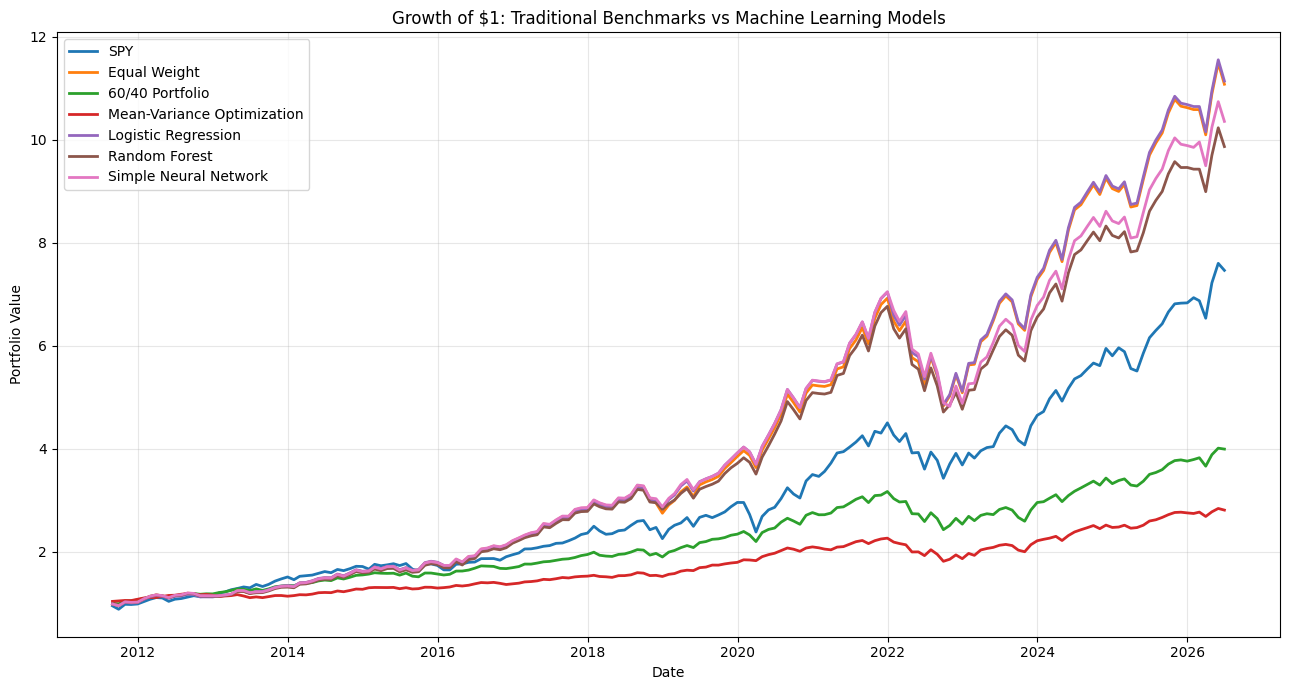

In [23]:
# ============================================================
# STAGE 11A: GROWTH OF $1
# ============================================================

growth_of_one = (
    1 + comparison_returns
).cumprod()

plt.figure(figsize=(13, 7))

for strategy in growth_of_one.columns:
    plt.plot(
        growth_of_one.index,
        growth_of_one[strategy],
        label=strategy,
        linewidth=2
    )

plt.title(
    "Growth of $1: Traditional Benchmarks vs Machine Learning Models"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()